# **Environment set up**

In [1]:
from PIL import Image

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
def save_gif_PIL(outfile, files, fps=5, loop=0):
    "Helper function for saving GIFs"
    imgs = [Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='GIF', append_images=imgs[1:], save_all=True, duration=int(1000/fps), loop=loop)

def oscillator(w0, x):
    """Defines the analytical solution to the 1D harmonic oscillator problem.
    This specific solution assumes initial conditions leading to y(0)=1, y'(0)=0.
    """
    # For an undamped harmonic oscillator, the equation is typically y(x) = A * cos(w0*x + phi).
    # The original function, when d=0, simplifies to y = cos(w0*x).
    y = torch.cos(w0 * x)
    return y

class FCN(nn.Module):
    "Defines a connected network"

    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

# **Generate training data**

torch.Size([500, 1]) torch.Size([500, 1])
torch.Size([10, 1]) torch.Size([10, 1])


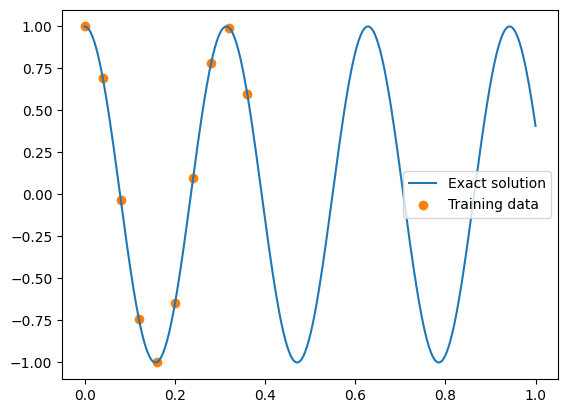

In [5]:
w0 = 20

# get the analytical solution over the full domain
x = torch.linspace(0,1,500).view(-1,1)
y = oscillator(w0, x).view(-1,1)
print(x.shape, y.shape)

# slice out a small number of points from the LHS of the domain
x_data = x[0:200:20]
y_data = y[0:200:20]
print(x_data.shape, y_data.shape)

plt.figure()
plt.plot(x, y, label="Exact solution")
plt.scatter(x_data, y_data, color="tab:orange", label="Training data")
plt.legend()
# plt.xlim(0, 1)
plt.show()


# **Normal neural network**

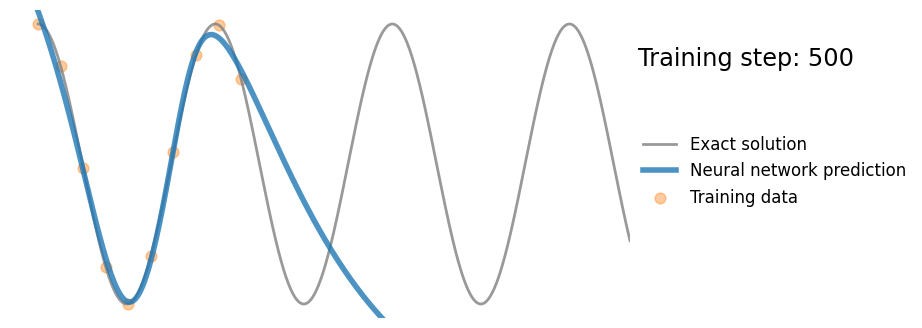

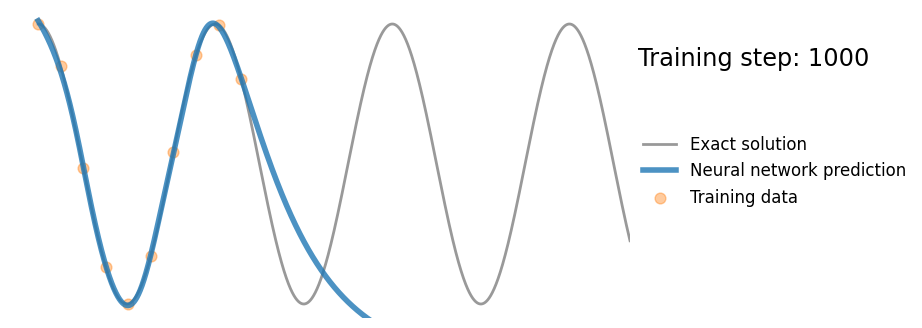

In [ ]:
def plot_result(x,y,x_data,y_data,yh,xp=None):
    "Pretty plot training results"
    plt.figure(figsize=(8,4))
    plt.plot(x,y, color="grey", linewidth=2, alpha=0.8, label="Exact solution")
    plt.plot(x,yh, color="tab:blue", linewidth=4, alpha=0.8, label="Neural network prediction")
    plt.scatter(x_data, y_data, s=60, color="tab:orange", alpha=0.4, label='Training data')
    if xp is not None:
        plt.scatter(xp, -0*torch.ones_like(xp), s=60, color="tab:green", alpha=0.4,
                    label='Physics loss training locations')
    l = plt.legend(loc=(1.01,0.34), frameon=False, fontsize="large")
    plt.setp(l.get_texts(), color="k")
    plt.xlim(-0.05, 1.05)
    plt.ylim(-1.1, 1.1)
    plt.text(1.065,0.7,"Training step: %i"%(i+1),fontsize="xx-large",color="k")
    plt.axis("off")


# train standard neural network to fit training data
torch.manual_seed(123)
model = FCN(1,1,32,3)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
files = []
for i in range(1000):
    optimizer.zero_grad()
    yh = model(x_data)
    loss = torch.mean((yh-y_data)**2)# use mean squared error
    loss.backward()
    optimizer.step()


    # plot the result as training progresses
    if (i+1) % 10 == 0:

        yh = model(x).detach()

        plot_result(x,y,x_data,y_data,yh)

        file = "nn_%.8i.png"%(i+1)
        plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)

        if (i+1) % 500 == 0: plt.show()
        else: plt.close("all")

save_gif_PIL("nn.gif", files, fps=20, loop=0)

# **PINN**

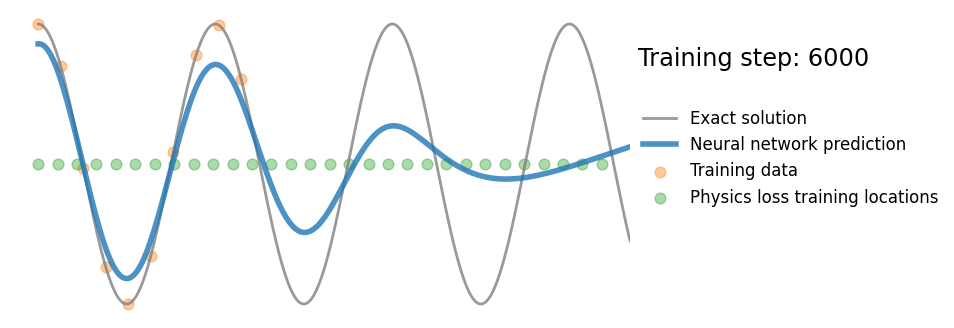

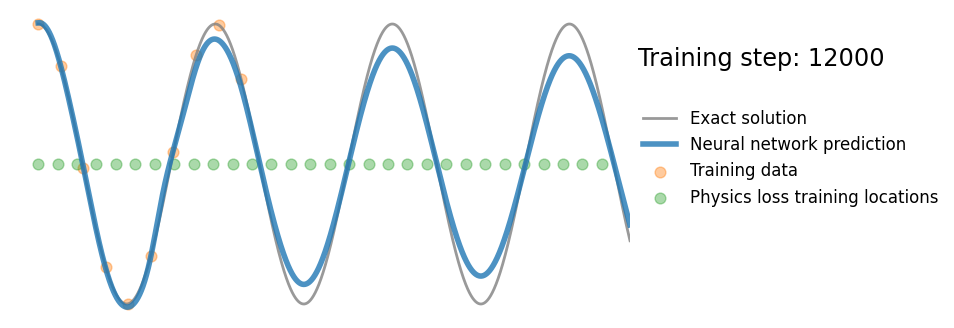

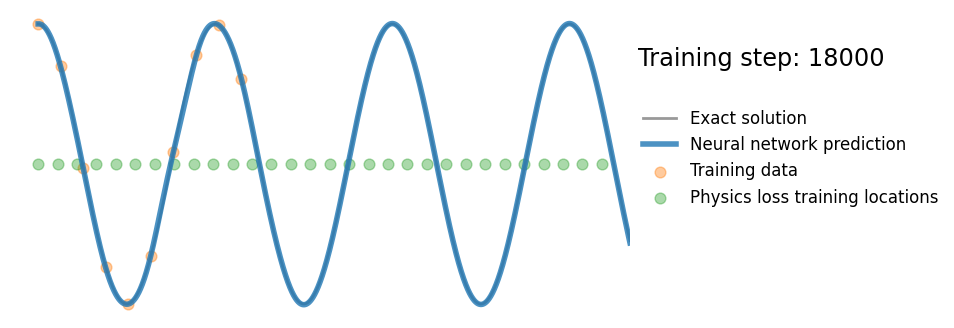

In [ ]:
x_physics = torch.linspace(0,1,30).view(-1,1).requires_grad_(True)# sample locations over the problem domain
mu, k = 0, w0**2

torch.manual_seed(123)
model = FCN(1,1,32,3)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)
files = []
for i in range(20000):
    optimizer.zero_grad()

    # compute the "data loss"
    yh = model(x_data)
    loss1 = torch.mean((yh-y_data)**2)# use mean squared error

    # compute the "physics loss"
    yhp = model(x_physics)
    dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]# computes dy/dx
    dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
    physics = dx2 + mu*dx + k*yhp # computes the residual of the 1D harmonic oscillator differential equation
    loss2 = (1e-4)*torch.mean(physics**2)

    # backpropagate joint loss
    loss = loss1 + loss2# add two loss terms together
    loss.backward()
    optimizer.step()


    # plot the result as training progresses
    if (i+1) % 150 == 0:

        yh = model(x).detach()
        xp = x_physics.detach()

        plot_result(x,y,x_data,y_data,yh,xp)

        file = "pinn_%.8i.png"%(i+1)
        plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)

        if (i+1) % 6000 == 0: plt.show()
        else: plt.close("all")

save_gif_PIL("pinn.gif", files, fps=20, loop=0)

# **Save model**

In [ ]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to save the model in Google Drive
save_dir = '/content/drive/My Drive/colab_models'
os.makedirs(save_dir, exist_ok=True)
model_save_path = os.path.join(save_dir, 'pinn_model7.pt')

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)

print(f"Model saved successfully to: {model_save_path}")

Mounted at /content/drive
Model saved successfully to: /content/drive/My Drive/colab_models/pinn_model7.pt


# **Load model**

In [ ]:
saved_model_path = '/content/drive/My Drive/colab_models/pinn_model7.pt'
# Create a new instance of the model with the same architecture
loaded_model = FCN(1, 1, 32, 3)

# Load the saved state dictionary
loaded_model.load_state_dict(torch.load(model_save_path))

# Set the model to evaluation mode (important for inference)
loaded_model.eval()

print("Model loaded successfully.")

Model loaded successfully.


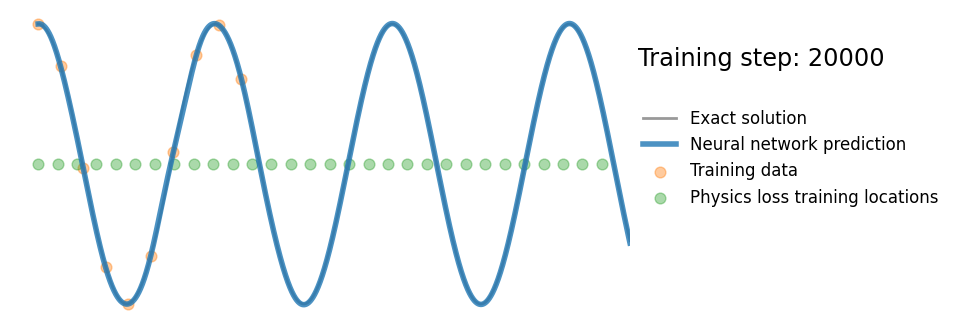

In [ ]:
yh_loaded = loaded_model(x).detach()

# Reuse the plot_result function for consistency
# The variable 'i' for 'Training step' will reflect the last training step from the PINN training.
plot_result(x, y, x_data, y_data, yh_loaded, xp=x_physics.detach())
plt.show()

# **History**

file name: `pinn_model.pt`

**solution data:** start = 0, end = 1, num = 500

**training data:** len(x) = 200 (step = 20) , len(y) = 200 (step = 20)

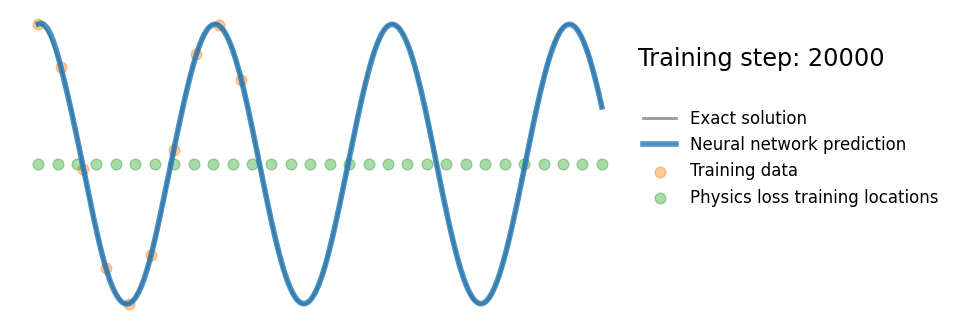

file name: `pinn_model1.pt`

start = 0, end = 10, num = 50000

len(x) = 200 (step = 20), len(y) = 200 (step = 20)

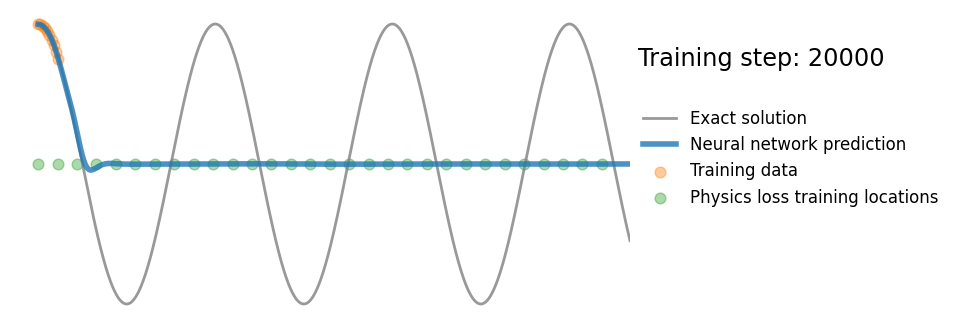

file name: `pinn_model2.pt`

start = 0, end = 10, num = 50000

len(x) = 20000 (step = 20), len(y) = 20000 (step = 20)

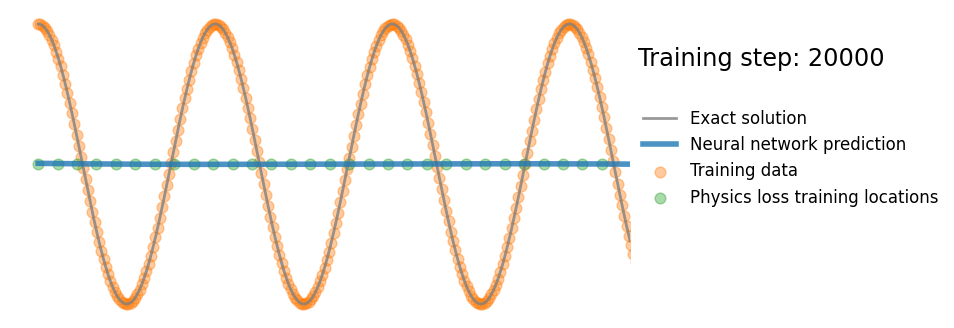

file name: `pinn_model3.pt`

start = 0, end = 10, num = 50000

len(x) = 2000 (step = 20), len(y) = 2000 (step = 20)

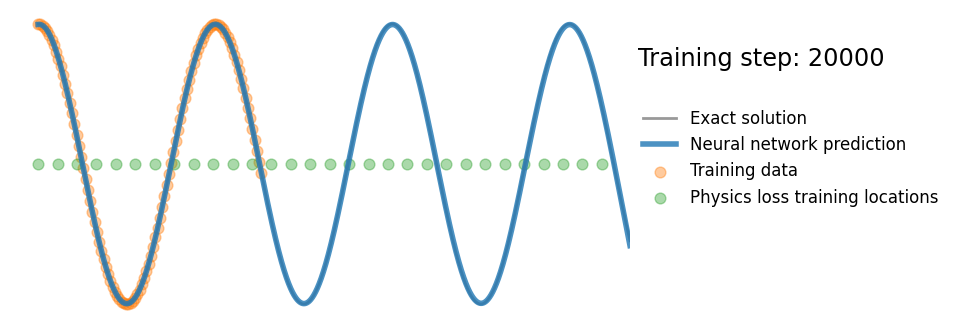

file name: `pinn_model4.pt`

start = 0, end = 10, num = 50000

len(x) = 1000 (step = 20), len(y) = 1000 (step = 20)

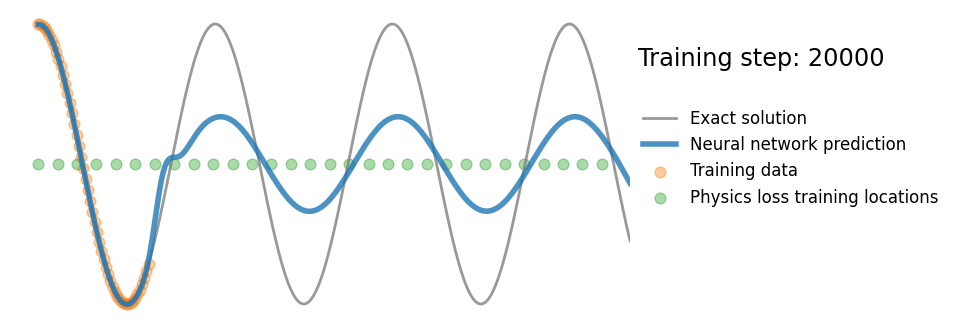

file name: `pinn_model6.pt`

start = 0, end = 10, num = 50000

len(x) = 2000 (step = 200), len(y) = 2000 (step = 200)

**This is the optimized solution for 1D harmonic oscillator!**

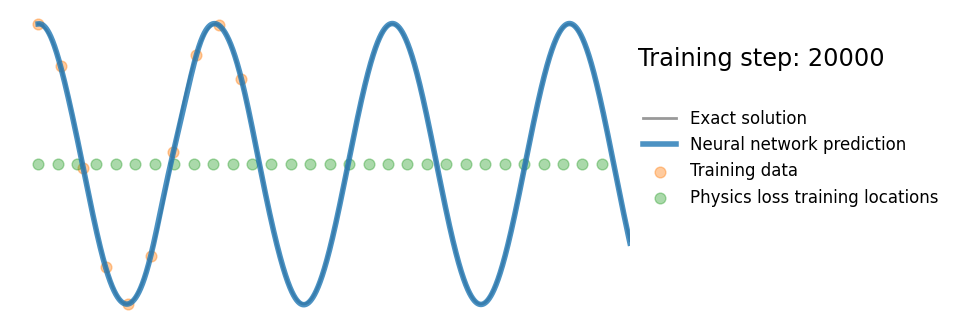